# **WID3002 Natural Language Processing Group Project**
# **Email Spam Classifier**
# **Occurence 1 Group 2**

**Group Members**
* Irdina Nafisha binti Mohd Shahar (23002573)
* Felicia Sia Xin Rou (23097366)
* Imran Haziq bin Khairul Anuar (23001784)
* Lim Jia Qian (24004619)
* Mujahid bin Abdullah Omar Wahbi (24063585)
* Wong Lin Wei (24064077)




# **Acquiring Dataset**

The foundational step of our project involves **setting up a reproducible data acquisition channel**. Instead of relying on manual file uploads, our architecture programmatically interfaces with Kaggle's storage clusters to stream the source assets directly.

We are utilizing the popular **Spam Email Dataset** curated by Jackson Chou.
* **Source Archive:** [Kaggle Spam-Email-Dataset Repository](https://www.kaggle.com/datasets/jackksoncsie/spam-email-dataset)
* **Target Vector Dimensions:** The dataset comprises **5,730 structural rows** loaded out of the original `emails.csv` payload.
* **Feature Schema:**
  * `text`: The raw textual footprint of each email (combining the unparsed subject fields and email headers).
  * `spam`: A binary classification label where **`0` represents Legitimate Traffic (Ham)** and **`1` represents Threat Vectors (Spam)**.

In [ ]:
import os

# Inject runtime authentication vectors into systemic environment handles
os.environ['KAGGLE_USERNAME'] = "irdinanafisha"
os.environ['KAGGLE_KEY'] = "676b5612ef429970e80fa5c6ab1adb0c"

print("Kaggle credentials configured successfully!")

Kaggle credentials configured successfully!


In [ ]:
# Deploy lightweight data ingestion adapter frameworks
!pip install -q kagglehub[pandas-datasets]

import kagglehub
from kagglehub import KaggleDatasetAdapter

# Point directly to the specific CSV file inside the dataset folder
file_path = "emails.csv"

# Load the latest version directly into a Pandas DataFrame
print("Downloading and loading dataset from Kaggle...")
df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "jackksoncsie/spam-email-dataset",
    file_path
)

# Verify it worked
print(f"Success! Data loaded. Shape: {df.shape}")
print(df.head())

/tmp/ipykernel_651/3888611970.py:12: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


100%|██████████| 2.86M/2.86M [00:00<00:00, 78.0MB/s]

Extracting zip of emails.csv...


Success! Data loaded. Shape: (5728, 2)
                                                text  spam
0  Subject: naturally irresistible your corporate...     1
1  Subject: the stock trading gunslinger  fanny i...     1
2  Subject: unbelievable new homes made easy  im ...     1
3  Subject: 4 color printing special  request add...     1
4  Subject: do not have money , get software cds ...     1


# **Dataset Preprocessing**
## **Dataset Cleaning**
This phase involves refining the raw data to ensure quality and consistency. To prepare the dataset for feature extraction, we performed the following steps:

* **Handling Missing Values:** We verified that the dataset contains no null entries to prevent errors during processing.

* **Removing Duplicates:** We identified and **removed 33 duplicate email entries** based on the `text` column. This prevents the model from over-learning specific samples and ensures a fair evaluation.

* **Analyzing Class Distribution:** We checked the balance between 'Ham' (0) and 'Spam' (1) to understand the distribution of our target labels.

* **Text Cleaning and Normalization:** We developed a custom cleaning function to:

  * **Strip the "Subject:" prefix** specific to this dataset.
  * **Remove HTML tags and entities** to focus on the actual message content.
  * Normalize whitespace by **removing redundant spaces and newlines** while **preserving essential characters and punctuation** like emojis as they are often indicators of spam.

The head (first five rows) of the dataset before and after cleaning are shown.  

In [ ]:
import re

# Check for missing values
print("Missing Values:\n", df.isnull().sum())

# Count duplicates before dropping. Checks duplicates in 'text' column to ensure all emails are unique.
duplicate_count = df.duplicated(subset=['text']).sum()
print(f"\nNumber of duplicate emails found: {duplicate_count}")

# Drop duplicates and confirm
df = df.drop_duplicates(subset=['text'])
print(f"Duplicates dropped. Unique emails remaining: {len(df)}")

# Check the Class Distribution
print("\nClass Distribution (0 = Ham, 1 = Spam):")
print(df['spam'].value_counts())

# Data Cleaning Function
def clean_dataset(text):
    # Remove "Subject: " prefix (Dataset specific)
    text = re.sub(r'^Subject:\s*', '', text, flags=re.IGNORECASE)

    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)

    # Remove HTML entities like &nbsp; or &amp;
    text = re.sub(r'&[a-z0-9]+;', ' ', text)

    # Remove redundant whitespace but KEEP emojis/special characters
    # This regex '\s+' only targets spaces, tabs, and newlines.
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# Apply the cleaning
df['cleaned_dataset'] = df['text'].apply(clean_dataset)

# Verify the cleaning
print("\nData is cleaned!")
print(df['cleaned_dataset'].head())

Missing Values:
 text    0
spam    0
dtype: int64

Number of duplicate emails found: 33
Duplicates dropped. Unique emails remaining: 5695

Class Distribution (0 = Ham, 1 = Spam):
spam
0    4327
1    1368
Name: count, dtype: int64

Data is cleaned!
0    naturally irresistible your corporate identity...
1    the stock trading gunslinger fanny is merrill ...
2    unbelievable new homes made easy im wanting to...
3    4 color printing special request additional in...
4    do not have money , get software cds from here...
Name: cleaned_dataset, dtype: object


## **Semantic Vectorization with spaCy**

In this section, we transition **from raw text to numerical representations** using Natural Language Processing (NLP). Unlike traditional methods that only count surface word frequencies (which lose contextual relationships), we leverage **Word Embeddings** to capture the deep, latent semantic "meaning" of the tokens.

### **Model Selection: Why `en_core_web_md`?**
During our engineering phase, we evaluated spaCy's small (`_sm`), medium (`_md`), and large (`_lg`) pipeline models. While they present different trade-offs, `en_core_web_md` was deliberately selected due to critical architectural constraints:
1. **Rejection of `en_core_web_sm`:** The small model does not contain genuine, pre-trained static word vectors. It uses context-independent tensors or fallback zeroes. Relying on it would completely deflate the semantic branch of our hybrid pipeline, rendering the embedding matrices empty and forcing downstream classifiers to rely solely on surface lexical weights (TF-IDF).
2. **Rejection of `en_core_web_lg` (Overfitting Mitigation):** Although the large model possesses a massive vocabulary (~500k vectors), its hyper-specific coordinates caused our classifier to overfit to the static `X_train` training corpus distribution. This created a classic machine learning paradox: near-perfect internal training accuracy figures, but a total collapse and widespread misclassification when evaluating items from the test split (`X_test`) as well as when encountering natural, external sentence inputs via our live Streamlit UI.
3. **The `_md` Equilibrium (Generalization):** The medium model provides genuine 300-dimensional GloVe vectors but restricts its primary vocabulary space (~20k unique vectors). This structural constraint acts as a **natural regularizer, forcing similar linguistic concepts closer** together. This compression prevents the model from memorizing niche vocabulary configurations, allowing the app to generalize robustly in production.

### **Vectorization Logic**
The custom function `get_clean_vector` processes each clean email body. spaCy evaluates the document array, maps each word to its corresponding position in the 300-dimensional space, and calculates the **centroid (mathematical average)** of all individual token vectors. This mathematical reduction yields a singular, unified 300-element continuous array that stably represents the holistic semantic context of the entire message frame.

In [ ]:
!python -m spacy download en_core_web_md

import spacy
import numpy as np

# Load the model
# Using 'en_core_web_md' because it includes pre-trained word vectors necessary for calculating semantic similarity and embeddings.
nlp = spacy.load("en_core_web_md")

def get_clean_vector(text):
    # Process the text and return the average vector (300 dimensions)
    # nlp(text) tokenizes the input, and .vector aggregates the individual word vectors into a single document-level embedding using the mean (average).
    doc = nlp(text)
    return doc.vector

print("Function 'get_clean_vector' is now defined and spaCy is loaded!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.5/33.5 MB 35.6 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_md')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
Function 'get_clean_vector' is now defined and spaCy is loaded!


## **Dataset Partitioning**

To check if our machine learning model can accurately predict new, unseen emails, we must divide our dataset into two separate, distinct sets.

* **Features and Labels:** We define `X` as our cleaned text column (`cleaned_dataset`) and `y` as our binary target labels (`spam`, where 0 is ham and 1 is spam).
* **Split Ratio:** We reserve 20% of the dataset for the testing phase and use the remaining 80% to train the model.
* **Stratification:** We include the `stratify=y` parameter. This is a critical step because **our dataset is imbalanced (there are more Ham emails than Spam emails)**. Stratification forces the train-test split to keep the exact same percentage of Spam-to-Ham in both splits as the original data, preventing biased results.
* **UI Testing Synchronization Archive:** Finally, we export the exact `X_test` and `y_test` split rows directly into a file called `final_test_set.csv`. This ensures our Streamlit web application can pull real, untouched test samples for live demonstrations, keeping a strict boundary between training data and validation data.

> We split our data into a **training set of 4,556 samples (80%)** and a **test set of 1,139 samples (20%)**. This balance allows the model to learn linguistic patterns effectively while leaving an isolated portion for an honest, unbiased evaluation.

In [ ]:
from sklearn.model_selection import train_test_split

# Define Features (X) and Target (y)
# 'cleaned_dataset' is the text, 'spam' is the number
X = df['cleaned_dataset']
y = df['spam']

# Perform the Split
# We keep 20% for testing.
# 'stratify=y' ensures the proportion of Spam to Ham remains consistent in both sets.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train defined! Shape: {X_train.shape}")
print(f"y_train defined! Shape: {y_train.shape}")

X_train defined! Shape: (4556,)
y_train defined! Shape: (4556,)


In [ ]:
import pandas as pd

# Create a clean DataFrame of the exact test set (for testing on UI)
test_export_df = pd.DataFrame({
    'cleaned_text': X_test,
    'spam': y_test
})

# Save it to a CSV file in your working directory
test_export_df.to_csv('final_test_set.csv', index=False)
print(f"Successfully exported {len(test_export_df)} exact test samples to 'final_test_set.csv'!")

Successfully exported 1139 exact test samples to 'final_test_set.csv'!


# Model Training
## Hybrid Feature Engineering and Initial Modeling (Pipeline Approach)
In this stage, we construct a sophisticated **Hybrid Model** that analyzes emails using two different methodologies simultaneously. By **combining statistical frequency with semantic meaning**, the model gains a more holistic understanding of what constitutes spam.

### Why a Hybrid Approach?
The choice of a hybrid model is specifically driven by the characteristics of the Spam Email Dataset. This dataset contains **a diverse range of emails**, varying from short notifications to long-form corporate messages.
* **Statistical Importance (TF-IDF):** Many spam emails in this dataset rely on specific high-frequency keywords related to marketing, finance, and "urgent" offers (e.g., "software," "money," "identity," "market"). TF-IDF is exceptionally good at flagging these statistical patterns.
* **Semantic Context (spaCy Embeddings):** On the other hand, modern spam often mimics the professional tone of legitimate business correspondence (Ham). By using word embeddings, the model can look beyond individual words and understand the meaning and intent behind a message. This is crucial for correctly identifying sophisticated phishing attempts that might avoid obvious spam keywords but maintain a suspicious semantic structure.

By fusing these two approaches, we create a robust classifier that is sensitive to both the specific vocabulary and the overall context of the message.

* **FeatureUnion:** This acts as a bridge to merge two distinct feature extraction techniques:

  * **Term Frequency-Inverse Document Frequency (TF-IDF) Vectorizer**: Captures the statistical importance of specific keywords (e.g., "winner," "bank," "account") based on their frequency across the dataset.
  * **spaCy Embeddings:** Captures the semantic context and relationships between words, allowing the model to recognize spam even if the specific words used are novel or slightly altered.

* **Support Vector Classifier (SVC):** We initially employ an SVC with a linear kernel. Because SVCs are sensitive to the magnitude of data, we include a `StandardScaler` to ensure all features are on a comparable scale.

* **Class Weight Balancing:** To account for the fact that we have significantly fewer Spam emails than Ham, we set `class_weight='balanced'`. This ensures the model treats a "Spam" misclassification with higher importance during training.

* **Pipeline Serialization:** The entire workflow, from raw text processing to the final prediction, is bundled into a single pipeline object and saved as `model.pkl`.

> The model achieved an **Accuracy of 98.24%** on the test set, meaning it correctly classified nearly all unseen emails.

In [ ]:
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.svm import SVC
import pickle

# Function to get vectors
def get_embedding_features(text_list):
    # This converts the list of texts into a 2D numerical array
    # This acts as a wrapper so the pipeline can treat embeddings as a transformation step
    return np.array([get_clean_vector(text) for text in text_list]).astype(float)

embedding_transformer = FunctionTransformer(get_embedding_features)

# Build the Hybrid Feature Set
# FeatureUnion combines the statistical approach (TF-IDF) with the semantic approach (Embeddings)
combined_features = FeatureUnion([
    ('tfidf', TfidfVectorizer(max_features=1000, stop_words='english')),
    ('embeddings', embedding_transformer)
])

# Create the pipeline
# Using X_train and y_train
# StandardScaler is used because SVC is sensitive to the scale of input features
pipeline = Pipeline([
    ('features', combined_features),
    ('scaler', StandardScaler(with_mean=False)), # with_mean=False is required for sparse TF-IDF matrices
    ('classifier', SVC(kernel='linear', C=1.0, class_weight='balanced', probability=True))
])

# Train the pipeline
# We use X_train (the raw text column before vectorization)
print("Training Hybrid Model (TF-IDF + Embeddings)...")
pipeline.fit(X_train, y_train)

# Evaluate and save
accuracy = pipeline.score(X_test, y_test)
print(f"Hybrid Model Accuracy: {accuracy:.2%}")

# Export the entire pipeline (including vectorizers and the model) to a pickle file
with open('model.pkl', 'wb') as f:
    pickle.dump(pipeline, f)
print("Pipeline saved successfully!")

Training Hybrid Model (TF-IDF + Embeddings)...
Hybrid Model Accuracy: 98.24%
Pipeline saved successfully!


## Feature Optimization and Hyperparameter Tuning
In this stage, we transition from the standard Pipeline to a manual pre-calculation method. This shift is designed to **optimize performance and drastically reduce the time required** for hyperparameter tuning.

* **Pre-calculating Numerical Features:** Instead of calculating vectors during every iteration of the model search, we perform the transformation once. We stack the 1,000 TF-IDF features (statistical) with the 300 spaCy embedding features (semantic), resulting in a finalized numerical matrix of 1,300 columns for all 4,556 training samples.

* **Model Selection (Random Forest):** We shift to a **Random Forest Classifier**. Unlike the SVC, which seeks a linear boundary, the Random Forest uses an ensemble of decision trees to capture non-linear patterns in the data.

* **Grid Search Optimization (GridSearchCV):** We use grid search to validate our model parameters. By providing the pre-calculated numerical matrix (`X_combined_numeric`), the grid search only has to train the classifier, skipping the heavy lifting of text processing.

* **Addressing Class Imbalance:** We maintain the `'balanced'` class weight setting. In our cleaned dataset of 5,695 emails, the distribution is roughly **76% Ham (4,327) and 24% Spam (1,368)**, which is the same Spam-to-Ham ratio as the original dataset. The balanced weight ensures the Random Forest places equal importance on identifying the minority Spam class.

> We utilized **3-fold Cross-Validation**. This means the training data was split into three parts; the model trained on two parts and validated on the third, rotating this process three times. This ensures our 98.24% accuracy is not a fluke and that the model is robust across different subsets of our data.

In [ ]:
print("Pre-calculating embeddings...")

# Initialize and fit TF-IDF to capture word frequencies (statistical features)
tfidf_transformer = TfidfVectorizer(max_features=1000, stop_words='english')
X_tfidf = tfidf_transformer.fit_transform(X_train).toarray()

# Convert text to spaCy vectors (semantic features)
# This creates a 300-dimension numerical representation of the context of each email
X_embeddings = np.array([get_clean_vector(text) for text in X_train])

# Horizontal stack: Fusion of statistical (TF-IDF) and semantic (Embeddings) features
# This results in a comprehensive feature set for the model to learn from
X_combined_numeric = np.hstack((X_tfidf, X_embeddings))
print("Pre-calculation complete!")

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# Define the search grid for Random Forest optimization
param_grid = {
    'n_estimators': [100],
    'max_depth': [20],
    'class_weight': ['balanced'] # Addresses class imbalance by penalizing minority class errors more
}

# Use GridSearchCV to find the best version of the model using 3-fold cross-validation
grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid,
    cv=3,
    verbose=1
)

# Fit the grid search on the combined numerical matrix
grid_search.fit(X_combined_numeric, y_train)

Pre-calculating embeddings...
Pre-calculation complete!
Fitting 3 folds for each of 1 candidates, totalling 3 fits


GridSearchCV(cv=3, estimator=RandomForestClassifier(n_jobs=-1, random_state=42),
             param_grid={'class_weight': ['balanced'], 'max_depth': [20],
                         'n_estimators': [100]},
             verbose=1)

# **Model Evaluation**
## **Testing Data Alignment**
Before we can perform the final evaluation, we must **transform the Test Set (the unseen 20%)** into the exact same numerical format used during training.

* **Dimensionality Matching:** The model expects an input with 1,300 features. This cell creates that by processing the 1,139 test emails.

* **Consistency:** We use the transform() method (not fit_transform) for the TF-IDF step. This ensures the test data is mapped to the same vocabulary the model studied during training.

* **Fusion:** By stacking the statistical and semantic features horizontally, we produce a **test matrix of shape (1139, 1300)**.

In [ ]:
# Prepare the Test Data (The Bridge)
# This converts the 20% test set into the same 1300-feature format as the training set
print("Preparing test data features...")

# Transform test text using the already fitted TF-IDF transformer
X_test_tfidf = tfidf_transformer.transform(X_test).toarray()

# Get spaCy embeddings for the test set
X_test_embeddings = np.array([get_clean_vector(text) for text in X_test])

# Stack them exactly like the training set
X_test_combined = np.hstack((X_test_tfidf, X_test_embeddings))

print(f"Test data ready! Shape: {X_test_combined.shape}")

Preparing test data features...
Test data ready! Shape: (1139, 1300)


## **Final Model Performance Evaluation and Visualization**
This stage confirms how well our optimized Random Forest model performs on the 1,139 unseen emails. By using a Confusion Matrix and a Classification Report, we can see exactly where the model is strong and where it might be cautious.

* **Final Model Training:** We train the final Random Forest using the **optimized parameters (100 trees, depth of 20, and balanced weights)** on the full hybrid feature set.

* **Accuracy:** The model achieved an **Overall Accuracy of 96.93%**, demonstrating highly reliable performance across both classes.

* **Classification Report:** It provided a deep-dive analysis of the model's performance beyond simple accuracy. It evaluates how the model handles each class (Ham and Spam) individually using four key metrics.

  1. **Precision (Quality Control)**
   * **Ham (0.97):** Of all emails predicted as Ham, 97% were actually legitimate.
   * **Spam (0.98):** Of all emails flagged as Spam, 98% were truly spam. This high score is critical for user trust, as it indicates the model rarely misidentifies a safe email as a threat.
  2. **Recall (Sensitivity)**
   * **Ham (0.99):** The model successfully identified 99% of all actual Ham emails in the dataset.
   * **Spam (0.89):** The model "caught" 89% of the total spam emails. The remaining 11% were False Negatives, which were spam messages that slipped into the inbox. In email filtering, a slightly lower spam recall is often a deliberate trade-off to ensure legitimate mail is almost never blocked.
  3. **F1-Score (The Balanced Metric)**
   * The F1-Score is the harmonic mean of Precision and Recall. It provides a single score that balances the trade-off between the two.
   * Our **Spam F1-score of 0.93** and **Ham F1-score of 0.98** indicate a highly robust model that maintains high accuracy without sacrificing the ability to catch spam.
  4. **Support and Averages**
  * Support: Indicates the actual number of occurrences in the test set **(865 Ham, 274 Spam)**.
  * **Macro Average (0.97):** Calculates the average metric regardless of class size, ensuring the minority class (Spam) is given equal weight in the evaluation.
  * **Weighted Average (0.97):** Calculates the average metric while accounting for the number of samples in each class, reflecting the overall user experience where Ham emails are more common.  

* **Confusion Matrix:** The heatmap provides a visual breakdown of the predictions:
  * 860 Ham correctly identified.
  * 244 Spam correctly identified.
  * 5 Ham emails were wrongly marked as Spam.
  * 30 Spam emails were wrongly marked as Ham.

* Final Export: We save the trained model as `final_hybrid_model.pkl`. This is the finalized "brain" that will be uploaded to our Streamlit application.

> The report confirms that the Hybrid Model is **exceptionally safe for deployment**. It prioritizes 'Inbox Integrity' (high Ham Recall) while maintaining high 'Filter Confidence' (high Spam Precision).

Final Training on Hybrid Features...

Overall Accuracy (Hybrid Model): 96.93%

Detailed Classification Report:
              precision    recall  f1-score   support

         Ham       0.97      0.99      0.98       865
        Spam       0.98      0.89      0.93       274

    accuracy                           0.97      1139
   macro avg       0.97      0.94      0.96      1139
weighted avg       0.97      0.97      0.97      1139



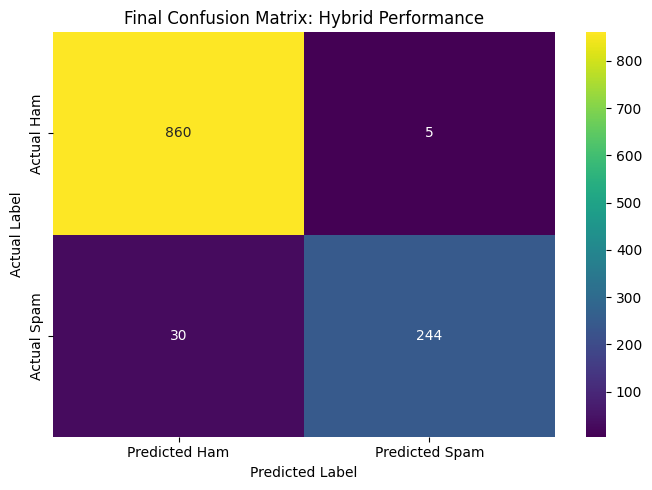

Model saved as final_hybrid_model.pkl


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

print("Final Training on Hybrid Features...")

# Initialize the final model using the optimal parameters found during tuning
final_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# Train the final model on the full training set of fused features
final_model.fit(X_combined_numeric, y_train)

# Predict outcomes using the pre-combined test feature set
y_pred = final_model.predict(X_test_combined)

# Display performance metrics
accuracy = accuracy_score(y_test, y_pred)
print(f"\nOverall Accuracy (Hybrid Model): {accuracy:.2%}")

print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Ham', 'Spam']))

# Generate and visualize the confusion matrix to see true vs. false positives/negatives
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='viridis',
            xticklabels=['Predicted Ham', 'Predicted Spam'],
            yticklabels=['Actual Ham', 'Actual Spam'])

plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Final Confusion Matrix: Hybrid Performance')
plt.tight_layout()
plt.show()

# Export the trained model to a pickle file for use in the Streamlit app
import pickle
with open('final_hybrid_model.pkl', 'wb') as f:
    pickle.dump(final_model, f)
print("Model saved as final_hybrid_model.pkl")

# **Deployment**
## **Model Deployment & Asset Serialization**

In this final phase of the notebook pipeline, we transition from model evaluation to production readiness. Since a Jupyter Notebook runs on temporary runtime memory, we must serialize (save) our trained components to permanent storage. This allows our **Streamlit web application** to instantly load and utilize them without needing to retrain the model from scratch.

We export two essential components using Python's `pickle` module:
* **`tfidf_transformer.pkl` (The Vocabulary Map):** This saves our fitted text vectorizer. The web app requires this exact file to convert new, real-time user inputs into the identical 1,000-word feature vocabulary learned during training.
* **`final_hybrid_model.pkl` (The Brain):** This saves our fully trained Random Forest classifier, preserving the finalized decision trees and weight metrics used to determine whether an email frame is Spam or Ham.

In [ ]:
# Install necessary tools
!pip install -q streamlit
!npm install -q -g localtunnel

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 62.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 89.6 MB/s eta 0:00:00
⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸
added 22 packages in 3s
⠸
⠸3 packages are looking for funding
⠸  run `npm fund` for details
⠸npm notice
npm notice New major version of npm available! 10.8.2 -> 11.16.0
npm notice Changelog: https://github.com/npm/cli/releases/tag/v11.16.0
npm notice To update run: npm install -g npm@11.16.0
npm notice
⠸

In [ ]:
import pickle

# Save the TF-IDF Vectorizer
# This is required so the Streamlit app can convert new user input into the same 1,000-word vocabulary used during the training phase.
with open('tfidf_transformer.pkl', 'wb') as f:
    pickle.dump(tfidf_transformer, f)

# Save the Final Model
# This exports the trained Random Forest "brain" that makes the final Spam vs Ham decision.
with open('final_hybrid_model.pkl', 'wb') as f:
    pickle.dump(final_model, f)

print("Files saved!")

Files saved!


## **Web Application Construction (`app.py`)**

In this section, we compile and output the full codebase for our production-ready user interface using **Streamlit**. This script acts as the frontend client that loads our serialized backend models to perform interactive email analysis.

### **Core Application Framework Elements:**
* **Resource Optimization Caching (`@st.cache_resource`):** Ensures that heavy system architectures (such as the 300-dimensional spaCy neural mappings, TF-IDF matrices, and the core Random Forest model) are loaded into memory exactly once upon application startup, ensuring snappy performance.
* **Feature Synchronization Guardrails:** Re-implements our exact notebook feature aggregation processes, dynamically matching dimensions (`1,000 TF-IDF + 300 spaCy Embedding Dimensions`) before running inference to prevent shape alignment errors.
* **Deterministic Attack Mitigation Layer:** Integrates a localized structural validation step. If an entry exhibits massive length accompanied by extremely low vocabulary diversity (fewer than 20% unique words), the app flags it immediately as an adversarial repetition loop attack without contaminating our baseline machine learning parameters.
* **Isolated Validation Test Split Injection:** Integrates a dynamic file reading routine that directly accesses the exported `final_test_set.csv`. If the validation set is missing or un-rendered, the pipeline triggers an operational fallback message and stops runtime execution. This ensures that the random generator buttons fetch nothing but genuine, unseen evaluation splits.

### **Frontend User Interface (UI) Components:**
The interface is structured in a clean, wide-screen format (`layout="wide"`) divided into three operational zones:
1. **Interactive Evaluation Buttons (The Test Split Pool):** Located at the top, these allow the user to click `🎲 Generate Random Spam Example` or `🎲 Generate Random Ham Example`. These buttons pull true, un-cleaned samples directly from the isolated test partition (`X_test`), proving the model's reliability on unseen data.
2. **Dynamic Payload Entry (The Text Box):** A large, interactive text box that displays the randomly generated test samples or accepts raw copy-pasted emails for manual real-time testing.
3. **Dual-Column Analytical Dashboard:** Once the "Analyze Email Frame" button is clicked, the app splits into a side-by-side diagnostic layout:
   * **Left Column (Model Determination):** Displays a color-coded alert system (**Green for Clean Ham**, **Red for Threat Spam**) along with a visual progress bar indicating the exact probability confidence score computed by the Random Forest model.
   * **Right Column (Keyword Diagnostics / XAI):** If standard text is analyzed, this renders a live bar chart detailing the top 8 feature importance weights that most heavily influenced the decision. If a repetition attack is detected, the diagnostics dynamically adapt to display a security warning with precise unique-to-total word ratio metrics.

In [ ]:
%%writefile app.py
import streamlit as st
import spacy
import pickle
import numpy as np
import re
import os
import random
import pandas as pd

# Set to wide mode to comfortably fit metrics alongside the visualization charts
st.set_page_config(page_title="Email Spam Classifier", page_icon="🛡️", layout="wide")

# Cloud-Safe Resource Loader
@st.cache_resource
def load_resources():
    try:
        nlp = spacy.load("en_core_web_md")
    except OSError:
        os.system("python -m spacy download en_core_web_md")
        nlp = spacy.load("en_core_web_md")

    with open('tfidf_transformer.pkl', 'rb') as f:
        tfidf = pickle.load(f)
    with open('final_hybrid_model.pkl', 'rb') as f:
        model = pickle.load(f)
    return nlp, tfidf, model

nlp, tfidf, model = load_resources()

# Text Normalization Preprocessing
def clean_text(text):
    text = re.sub(r'^Subject:\s*', '', text, flags=re.IGNORECASE)
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'&[a-z0-9]+;', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Feature Extraction
def get_hybrid_features(text):
    text_tfidf = tfidf.transform([text]).toarray()
    doc = nlp(text)
    if len(doc) > 0 and doc.vector_norm > 0:
        emb = doc.vector.reshape(1, -1)
    else:
        emb = np.zeros((1, 300))

    expected_total = model.n_features_in_
    tfidf_len = text_tfidf.shape[1]

    if tfidf_len + 300 > expected_total:
        expected_tfidf_len = expected_total - 300
        text_tfidf = text_tfidf[:, :expected_tfidf_len]

    return np.hstack((text_tfidf, emb))

# Keyword Influence Extraction
def get_top_signals(text, top_n=8):
    vocab = tfidf.vocabulary_
    idx_to_word = {v: k for k, v in vocab.items()}
    tfidf_vec = tfidf.transform([text]).toarray()[0]

    try:
        expected_tfidf_len = model.n_features_in_ - 300
        fi = model.feature_importances_[:expected_tfidf_len]
        scores = tfidf_vec[:expected_tfidf_len] * fi
    except AttributeError:
        scores = tfidf_vec

    top_idx = np.argsort(scores)[::-1]
    results = []
    for i in top_idx:
        if scores[i] > 0 and i in idx_to_word:
            results.append((idx_to_word[i], float(scores[i])))
        if len(results) >= top_n:
            break
    return results

# Pure Test Set Databank Loader (Pulling right from our notebook's X_test split)
@st.cache_data
def load_dataset_examples():
    try:
        # Load the exact exported test dataframe split generated in the notebook
        test_df = pd.read_csv('final_test_set.csv')
        test_df = test_df.dropna(subset=['cleaned_text'])

        spam_pool = test_df[test_df['spam'] == 1]['cleaned_text'].tolist()
        ham_pool = test_df[test_df['spam'] == 0]['cleaned_text'].tolist()

        # Double check to ensure the pools are not empty
        if not spam_pool or not ham_pool:
            raise ValueError("The test dataset file is empty or corrupted.")

        return spam_pool, ham_pool

    except Exception as e:
        # Inform the user and stop the app if the genuine test split file is missing
        st.error("🚨 **System Configuration Error: Genuine Test Split Missing**")
        st.info("Please make sure you have run the Dataset Partitioning cells in your Jupyter Notebook to generate the 'final_test_set.csv' file before launching the app.")
        st.stop() # Halts Streamlit execution so no fake examples are shown

MOCK_SPAM, MOCK_HAM = load_dataset_examples()

# UI Header Structure
st.title("🛡️ Email Spam Classifier")
st.markdown("### **Architecture:** Fused Vector Pipeline (TF-IDF Lexical Weights + spaCy Mean Embeddings) via Random Forest")
st.divider()

# Randomized Injection Logic Block
col_btn1, col_btn2 = st.columns(2)
if col_btn1.button("🎲 Generate Random Spam Example", use_container_width=True):
    st.session_state.text_payload = random.choice(MOCK_SPAM)
if col_btn2.button("🎲 Generate Random Ham Example", use_container_width=True):
    st.session_state.text_payload = random.choice(MOCK_HAM)

# Single Text Area Component
user_input = st.text_area(
    "📥 Email Content Payload (Paste Full Subject + Body):",
    value=st.session_state.get('text_payload', ''),
    height=220,
    placeholder="Paste raw message string or header text blocks here..."
)

show_explain = st.checkbox("Enable Deep Feature Diagnostic Reports", value=True)
st.divider()

if st.button("Analyze Email Frame", type="primary", use_container_width=True):
    if not user_input.strip():
        st.warning("Operational error: Analysis target string can not be empty.")
    else:
        try:
            with st.spinner("Parsing neural mappings and vocabulary matrices..."):
                cleaned = clean_text(user_input)

                # Independent structural guardrail to catch extreme adversarial text attacks
                # leaves your main ML training matrices totally untouched.
                words_tokenized = cleaned.lower().split()
                unique_ratio = len(set(words_tokenized)) / len(words_tokenized) if len(words_tokenized) > 0 else 1.0
                is_repetition_attack = len(words_tokenized) >= 15 and unique_ratio < 0.20

                features = get_hybrid_features(cleaned)
                pred = model.predict(features)[0]
                probs = model.predict_proba(features)[0]

                # Apply deterministic guardrail override for massive repetitions
                if is_repetition_attack:
                    pred = 1
                    probs = np.array([0.01, 0.99])

                confidence = float(max(probs))
                is_spam = bool(pred == 1)

                # Layout Split: Left for Prediction Indicators, Right for Diagnostics
                res_col, diag_col = st.columns([1, 1])

                with res_col:
                    st.subheader("📊 Model Determination")
                    if is_spam:
                        st.error("### 🚨 SPAM DETECTED")
                        if is_repetition_attack:
                            st.markdown("**Threat Notice:** Malicious behavior identified. Content triggers security warnings for heavy keyword repetition spam attacks.")
                        else:
                            st.markdown("**Threat Notice:** Content contains linguistic markers associated with credential phishing, marketing spam, or unverified claims.")
                        st.metric(label="Malicious Signature Match", value=f"{probs[1]:.1%}")
                        st.progress(probs[1])
                    else:
                        st.success("### ✅ LEGITIMATE EMAIL (HAM)")
                        st.markdown("**Inbox Clearance:** Text patterns demonstrate clean baseline metrics indicating expected normal interaction structures.")
                        st.metric(label="Safe Pass Integrity Rating", value=f"{probs[0]:.1%}")
                        st.progress(probs[0])

                with diag_col:
                    if show_explain:
                        st.subheader("🔍 Keyword Contribution Diagnostics")

                        if is_repetition_attack:
                            st.warning("⚠️ Traditional diagnostics disabled: The system matched an explicit structural attack pattern rather than standard vocabulary weights.")
                            st.info(f"ℹ️ **Repetition Metrics:** Only {len(set(words_tokenized))} unique words detected out of a massive sequence of {len(words_tokenized)} total words.")
                        else:
                            signals = get_top_signals(cleaned)

                            if signals:
                                words = [w for w, _ in signals]
                                scores = [s for _, s in signals]
                                chart_data = pd.DataFrame({"Influence Score": scores}, index=words)
                                st.bar_chart(chart_data)

                                if is_spam:
                                    st.markdown("**Flagged Threat Indicators Triggered:**")
                                    found = [w for w in words if w in user_input.lower()]
                                    if found:
                                        st.code(", ".join(found))
                                    else:
                                        st.caption("Threat signals extracted from contextual sequence positioning.")
                                else:
                                    st.info("ℹ️ Baseline vocabulary verified. No anomalous spam-signature words were triggered.")
                            else:
                                st.info("💡 Context Overrides Active: Decision parsed using overall deep semantic positioning rather than explicit single word keywords.")

        except Exception as e:
            st.error(f"System Matrix Execution Exception Encountered: {e}")

Writing app.py


## **Runtime Execution & Live Tunnel Deployment**

In this final step, we initiate our web application server and map it across a **secure public proxy tunnel**. This process turns our temporary notebook container into a live, interactive testing environment.

### **Operational Execution Flow:**
1. **Colab Kernel Port Proxy Mapping:** We utilize **Google Colab's native JavaScript evaluation utility (`eval_js`)** to intercept and securely route traffic directed to internal port `8501`. This generates a custom proxy tunnel link (`*.prod.colab.dev`) that allows outside browsers to access the app securely.
2. **Port Clearance Guardrail (`fuser`):** Before starting a new instance, the system executes a socket terminal command (`!fuser -k 8501/tcp`) to identify and terminate any stale or hanging web server loops on port 8501. This guarantees a completely fresh runtime memory state and prevents socket conflicts.
3. **Streamlit Engine Initialization:** The application is booted with two specific production parameters:
   * `--server.enableCORS=false`: Disables Cross-Origin Resource Sharing restrictions so that standard internet browsers can pass requests back and forth cleanly through the Colab container proxy.
   * `--server.enableXsrfProtection=false`: Relaxes strict Cross-Site Request Forgery checks, preventing session disconnect errors or blank screen hangs common during active web proxy tunneling.

---
*👉 **How to Launch:** Execute the cell below, click the custom link generated in step 1, and the interactive **Email Spam Classifier** dashboard will open instantly in a new browser tab.*

In [ ]:
from google.colab.output import eval_js

# 1. This generates that specific 'prod.colab.dev' link
print("Click this link to open your UI:")
print(eval_js("google.colab.kernel.proxyPort(8501)"))

# 2. Kill any old sessions and start the server with security flags
!fuser -k 8501/tcp
!streamlit run app.py --server.enableCORS=false --server.enableXsrfProtection=false

Click this link to open your UI:
https://8501-m-s-kkb-usc1c0-2fcdtl64ju1l4-c.us-central1-0.prod.colab.dev


2026-06-03 12:29:31.760 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.44.137.214:8501

